# Segment Level Results

In [327]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

segments = pd.read_csv("RESULTS/SEGMENTS_MAIN_MODEL.csv")
results = pd.read_csv("RESULTS/RESULTS_MAIN_MODEL.csv")
false_positives = pd.read_csv("RESULTS/FALSE_POSITIVES_MAIN_MODEL.csv")
events = pd.read_csv("RESULTS/EVENTS_MAIN_MODEL.csv")


# 1. Segment-Level Analysis

In [328]:
segments.head()

,C,gamma,k_feat,patient,record,n_windows,n_seizure_windows,record_length,threshold,k,roc_auc,ap,seg_accuracy,seg_specificity,seg_sensitivity,seg_precision,seg_f1,tp,fp,fn
0,1.0,0.0010,60,chb01,chb01_03,1437,16,3600.0,0,3,0.973126,0.229434,0.974252,0.979592,0.500000,0.216216,0.301887,8,29,8
1,0.1,0.0100,80,chb01,chb01_04,1437,11,3600.0,0,3,0.987824,0.321149,0.979123,0.980365,0.818182,0.243243,0.375000,9,28,2
2,10.0,0.0010,60,chb01,chb01_15,1437,16,3600.0,0,3,0.708612,0.031609,0.953375,0.963406,0.062500,0.018868,0.028986,1,52,15
3,1.0,0.0010,60,chb01,chb01_16,1437,21,3600.0,0,3,0.981168,0.359620,0.965205,0.968220,0.761905,0.262295,0.390244,16,45,5
4,100.0,0.0001,40,chb01,chb01_18,1437,37,3600.0,0,3,0.999035,0.975499,0.993737,0.995714,0.918919,0.850000,0.883117,34,6,3


In [329]:
segments.columns

Index(['C', 'gamma', 'k_feat', 'patient', 'record', 'n_windows',
       'n_seizure_windows', 'record_length', 'threshold', 'k', 'roc_auc', 'ap',
       'seg_accuracy', 'seg_specificity', 'seg_sensitivity', 'seg_precision',
       'seg_f1', 'tp', 'fp', 'fn'],
      dtype='object')

In [330]:
segments= segments[[ 'patient','record','n_windows','n_seizure_windows', 'roc_auc', 'ap',
       'seg_accuracy', 'seg_specificity', 'seg_sensitivity', 'seg_precision',
       'seg_f1','tp', 'fp', 'fn']].copy()


In [331]:
segment_nan = segments[segments["n_seizure_windows"] > 0].copy()

In [332]:
import pandas as pd

# ----------------------------
# Helper functions
# ----------------------------
def pooled_metrics(df):
    tp = df["tp"].sum()
    fp = df["fp"].sum()
    fn = df["fn"].sum()

    sensitivity = tp / (tp + fn) if (tp + fn) else float("nan")
    precision  = tp / (tp + fp) if (tp + fp) else float("nan")
    f1 = (
        2 * precision * sensitivity / (precision + sensitivity)
        if (precision + sensitivity)
        else float("nan")
    )

    return tp, fp, fn, sensitivity, precision, f1


def median_patient_metrics(df):
    patient_metrics = (
        df.groupby("patient")[[
            "seg_sensitivity",
            "seg_precision",
            "seg_f1"
        ]]
        .median()
    )

    return (
        patient_metrics["seg_sensitivity"].median(),
        patient_metrics["seg_precision"].median(),
        patient_metrics["seg_f1"].median(),
    )



In [333]:

# ==========================================================
# 1) All records, pooled (micro-average)
# ==========================================================
tp, fp, fn, sens, prec, f1 = pooled_metrics(segments)

table_all_micro = pd.DataFrame({
    "Evaluation scope": ["All records, pooled (micro-average)"],
    "n_records": [len(segments)],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "Sensitivity": [sens],
    "Precision": [prec],
    "F1": [f1],
})

table_all_micro.round(3)

# ==========================================================
# 2) Median across patients (macro)
# ==========================================================
sens, prec, f1 = median_patient_metrics(segments)

table_macro = pd.DataFrame({
    "Evaluation scope": ["Median across patients (macro)"],
    "n_patients": [segments["patient"].nunique()],
    "Sensitivity": [sens],
    "Precision": [prec],
    "F1": [f1],
})

print(table_macro.round(3))


# ==========================================================
# 3) Seizure-containing records only, pooled
# ==========================================================
tp, fp, fn, sens, prec, f1 = pooled_metrics(segment_nan)

table_seizure_micro = pd.DataFrame({
    "Evaluation scope": ["Seizure-containing records only, pooled"],
    "n_records": [len(segment_nan)],
    "TP": [tp],
    "FP": [fp],
    "FN": [fn],
    "Sensitivity": [sens],
    "Precision": [prec],
    "F1": [f1],
})

print(table_seizure_micro.round(3))



                 Evaluation scope  n_patients  Sensitivity  Precision     F1
0  Median across patients (macro)          24        0.478      0.355  0.398
                          Evaluation scope  n_records    TP    FP    FN  \
0  Seizure-containing records only, pooled        138  1953  4476  2516   

   Sensitivity  Precision     F1  
0        0.437      0.304  0.358  


In [334]:
summary = pd.DataFrame([
    {
        "Evaluation scope": "All records, pooled (micro-average)",
        "n": len(segments),
        **dict(zip(
            ["TP","FP","FN","Sensitivity","Precision","F1"],
            pooled_metrics(segments)
        ))
    },
    {
        "Evaluation scope": "Median across patients (macro)",
        "n": segments["patient"].nunique(),
        "TP": "—",
        "FP": "—",
        "FN": "—",
        "Sensitivity": median_patient_metrics(segments)[0],
        "Precision": median_patient_metrics(segments)[1],
        "F1": median_patient_metrics(segments)[2],
    },
    {
        "Evaluation scope": "Seizure-containing records only, pooled",
        "n": len(segment_nan),
        **dict(zip(
            ["TP","FP","FN","Sensitivity","Precision","F1"],
            pooled_metrics(segment_nan)
        ))
    },
])

summary.round(3)

,Evaluation scope,n,TP,FP,FN,Sensitivity,Precision,F1
0,"All records, pooled (micro-average)",683,1953,13300,2516,0.437,0.128,0.198
1,Median across patients (macro),24,—,—,—,0.478,0.355,0.398
2,"Seizure-containing records only, pooled",138,1953,4476,2516,0.437,0.304,0.358


## 1.1 False positive burden

In [335]:
segments["fp_per_1000_windows"] = (
    segments["fp"] / segments["n_windows"] * 1000
)

In [336]:
fp_density = (
    segments
    .groupby("patient")
    .agg(
        fp=("fp", "sum"),
        n_windows=("n_windows", "sum"),
    )
)

fp_density["fp_per_1000_windows"] = (
    fp_density["fp"] / fp_density["n_windows"] * 1000
)

fp_density = fp_density.sort_values("fp_per_1000_windows", ascending=False)

print(fp_density.round(2))

           fp  n_windows  fp_per_1000_windows
patient                                      
chb15    1695      69494                24.39
chb12     657      31647                20.76
chb08     508      30192                16.83
chb13     966      59421                16.26
chb19     820      55967                14.65
chb03     933      69489                13.43
chb07    1130     124646                 9.07
chb11     505      58637                 8.61
chb05     606      72368                 8.37
chb20     407      49753                 8.18
chb23     337      46662                 7.22
chb16     237      33543                 7.07
chb17     256      37689                 6.79
chb04    1935     294392                 6.57
chb02     406      66515                 6.10
chb01     305      58265                 5.23
chb14     235      46482                 5.06
chb21     218      61096                 3.57
chb24     115      35063                 3.28
chb06     346     115647          

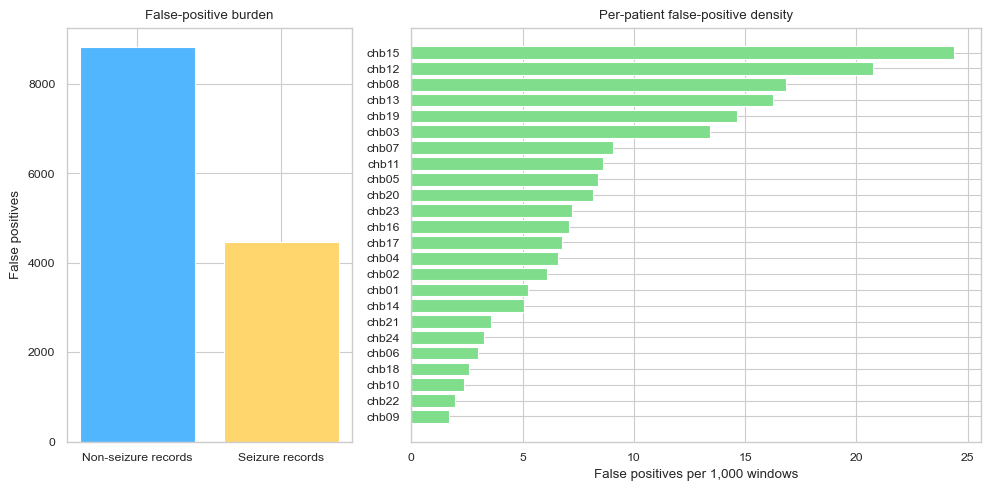

In [337]:

# -----------------------------------
# Colors
# -----------------------------------
GREEN = "#80dd8c"
YELLOW = "#ffd56e"
BLUE = "#52b6ff"

# -----------------------------------
# False-positive burden
# -----------------------------------
segments = segments.copy()
segments["has_seizure"] = segments["n_seizure_windows"] > 0

fp_burden = (
    segments
    .groupby("has_seizure")["fp"]
    .sum()
    .rename({
        True: "Seizure records",
        False: "Non-seizure records"
    })
)

# -----------------------------------
# False-positive density
# -----------------------------------
fp_density = (
    segments
    .groupby("patient")
    .agg(
        fp=("fp", "sum"),
        n_windows=("n_windows", "sum")
    )
)

fp_density["fp_per_1000_windows"] = (
    fp_density["fp"] / fp_density["n_windows"] * 1000
)

# Order from lowest to highest
fp_density = fp_density.sort_values("fp_per_1000_windows")

# -----------------------------------
# Plot
# -----------------------------------
fig, axes = plt.subplots(
    1, 2,
    figsize=(10, 5),
    gridspec_kw={"width_ratios": [1, 2]}
)

# Left: False-positive burden
colors = [
    YELLOW if label == "Seizure records" else BLUE
    for label in fp_burden.index
]

axes[0].bar(
    fp_burden.index,
    fp_burden.values,
    color=colors
)

axes[0].set_ylabel("False positives")
axes[0].set_title("False-positive burden")

# Right: Per-patient false-positive density
axes[1].barh(
    fp_density.index,
    fp_density["fp_per_1000_windows"],
    color=GREEN
)

axes[1].set_xlabel("False positives per 1,000 windows")
axes[1].set_title("Per-patient false-positive density")

plt.tight_layout()
plt.show()

In [338]:
import matplotlib.pyplot as plt

GREEN = "#0fe071"
YELLOW = "#f4c542"
BLUE = "#4f81bd"

# ---------- Data for left panel ----------
labels = ["Seizure-free\nrecords", "Seizure-containing\nrecords"]
values = [fp_density_non, fp_density_seiz]
colors = [BLUE, YELLOW]

# ---------- Data for right panel ----------
plot = summary.reset_index()

false = plot[plot["has_seizure"] == False].set_index("patient")
true = plot[plot["has_seizure"] == True].set_index("patient")

order = (
    true["fp_per_1000_windows"] -
    false["fp_per_1000_windows"]
).sort_values(ascending=False).index

false = false.loc[order]
true = true.loc[order]

# ---------- Figure ----------
fig, (ax1, ax2) = plt.subplots(
    1, 2,
    figsize=(15, 6),
    gridspec_kw={"width_ratios": [1, 2]}
)

# ========================================
# Left panel
# ========================================

bars = ax1.bar(
    labels,
    values,
    color=colors,
    width=0.6
)

for bar in bars:
    h = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.3,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

ax1.set_ylabel("False positives per 1,000 windows")
ax1.set_ylim(0, max(values) * 1.2)
ax1.set_title("(a) Pooled")

# ========================================
# Right panel
# ========================================

for i, patient in enumerate(order):
    ax2.plot(
        [
            false.loc[patient, "fp_per_1000_windows"],
            true.loc[patient, "fp_per_1000_windows"]
        ],
        [i, i],
        color="lightgray",
        lw=2,
        zorder=1
    )

ax2.scatter(
    false["fp_per_1000_windows"],
    range(len(order)),
    color=BLUE,
    s=60,
    label="Non-seizure records",
    zorder=2
)

ax2.scatter(
    true["fp_per_1000_windows"],
    range(len(order)),
    color=YELLOW,
    s=60,
    label="Seizure-containing records",
    zorder=3
)

ax2.set_yticks(range(len(order)))
ax2.set_yticklabels(order)
ax2.invert_yaxis()

ax2.set_xlabel("False positives per 1,000 windows")
ax2.set_title("(b) Per patient")


plt.subplots_adjust(wspace=0.2, right=0.8)
plt.show()

KeyError: 'has_seizure'

## 1.2 Sensitivity vs. Precision

patient  recs  sz_recs  prevalence   auc    ap  sensitivity  precision    f1  fp_per_1k
  chb01    42        7        0.31 0.949 0.547        0.728      0.300 0.425        5.2
  chb02    36        3        0.11 0.745 0.180        0.286      0.047 0.081        6.1
  chb03    38        7        0.23 0.903 0.207        0.325      0.054 0.092       13.4
  chb04    42        3        0.05 0.894 0.190        0.243      0.019 0.035        6.6
  chb05    39        5        0.31 0.954 0.660        0.616      0.185 0.285        8.4
  chb06    18        7        0.06 0.764 0.175        0.344      0.060 0.102        3.0
  chb07    19        3        0.12 0.767 0.157        0.253      0.033 0.058        9.1
  chb08    20        5        1.22 0.843 0.509        0.450      0.245 0.317       16.8
  chb09    19        3        0.09 0.955 0.555        0.505      0.215 0.301        1.7
  chb10    25        7        0.22 0.955 0.612        0.588      0.350 0.439        2.4
  chb11    35        3        0.

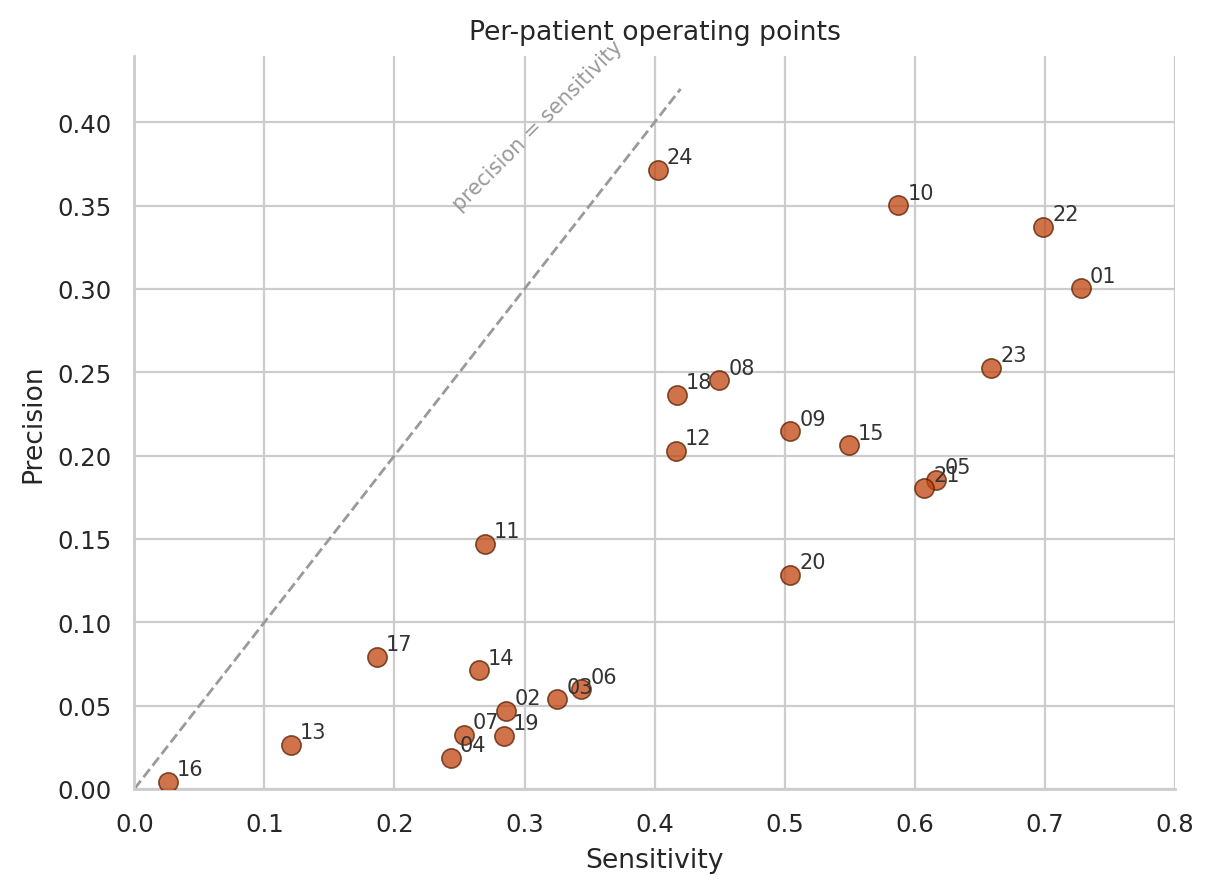

In [348]:

"""
Per-patient segment-level results: Table 2 + Figure 2 (sensitivity vs precision).
 
Input : RECORD_LEVEL_SEGMENT_RESULTS.csv
        (one row per record; columns include patient, record, n_windows,
         n_seizure_windows, roc_auc, ap, tp, fp, fn)
Output: per_patient_table.csv  and  figure2_sens_vs_prec.png
"""
 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
 
CSV = "RESULTS/RECORD_LEVEL_SEGMENT_RESULTS.csv"
 
# ---------------------------------------------------------------------------
# 1. Per-patient metrics (Table 2)
#    Metrics are POOLED within each patient: sum the TP/FP/FN counts across
#    all of that patient's records, then compute the rates from the totals.
#    (This is a micro-average per patient, not the mean of per-record rates.)
# ---------------------------------------------------------------------------
df = pd.read_csv(CSV)
 
g = (df.groupby("patient")
       .agg(recs=("record", "count"),                              # total records
            sz_recs=("n_seizure_windows", lambda x: (x > 0).sum()),# seizure records
            win=("n_windows", "sum"),                              # total windows
            sz=("n_seizure_windows", "sum"),                       # seizure windows
            tp=("tp", "sum"),
            fp=("fp", "sum"),
            fn=("fn", "sum"),
            auc=("roc_auc", "mean"),                               # mean over records
            ap=("ap", "mean"))
       .reset_index())
 
g["sensitivity"] = g.tp / (g.tp + g.fn)          # recall
g["precision"]   = g.tp / (g.tp + g.fp)
g["f1"]          = 2 * g.precision * g.sensitivity / (g.precision + g.sensitivity)
g["prevalence"]  = g.sz / g.win                  # fraction of windows that are seizure
g["fp_per_1k"]   = g.fp / g.win * 1000           # false-positive density
 
# Table 2, ordered and rounded for reporting
table = g[["patient", "recs", "sz_recs", "prevalence", "auc", "ap",
           "sensitivity", "precision", "f1", "fp_per_1k"]].copy()
table["prevalence"] = table["prevalence"] * 100  # as a percentage
table = table.round({"prevalence": 2, "auc": 3, "ap": 3,
                     "sensitivity": 3, "precision": 3, "f1": 3, "fp_per_1k": 1})
table.to_csv("per_patient_table.csv", index=False)
print(table.to_string(index=False))
 
# ---------------------------------------------------------------------------
# 2. Correlations reported in the text
#    Spearman = Pearson correlation of the ranks (no scipy needed).
# ---------------------------------------------------------------------------
def pearson(a, b):
    return np.corrcoef(a, b)[0, 1]
 
def spearman(a, b):
    ra, rb = pd.Series(a).rank(), pd.Series(b).rank()
    return np.corrcoef(ra, rb)[0, 1]
 
print(f"\nprecision ~ sensitivity : Pearson {pearson(g.precision, g.sensitivity):.3f}, "
      f"Spearman {spearman(g.precision, g.sensitivity):.3f}")
print(f"precision ~ prevalence  : Pearson {pearson(g.precision, g.prevalence):.3f}, "
      f"Spearman {spearman(g.precision, g.prevalence):.3f}")
 
# ---------------------------------------------------------------------------
# 3. Figure 2 : per-patient operating points (sensitivity vs precision)
# ---------------------------------------------------------------------------
plt.rcParams.update({"font.size": 11, "font.family": "DejaVu Sans",
                     "axes.spines.top": False, "axes.spines.right": False,
                     "figure.dpi": 200})
ORANGE, GREY = "#c1440e", "#9a9a9a"
 
fig, ax = plt.subplots(figsize=(6.2, 4.6))
ax.plot([0, 0.42], [0, 0.42], ls="--", color=GREY, lw=1, zorder=1)      # precision = sensitivity
ax.text(0.31, 0.345, "precision = sensitivity", rotation=45,
        fontsize=7.5, color=GREY, ha="center", va="bottom")
ax.scatter(g.sensitivity, g.precision, s=48, color=ORANGE, alpha=0.75,
           edgecolor="#5a2004", linewidth=0.6, zorder=3)
for x, y, name in zip(g.sensitivity, g.precision, g.patient):
    ax.annotate(name.replace("chb", ""), (x, y), fontsize=7.5, color="#333",
                xytext=(x + 0.007, y + 0.004), textcoords="data")
 
ax.set_xlabel("Sensitivity")
ax.set_ylabel("Precision")
ax.set_title("Per-patient operating points")
ax.set_xlim(0, 0.8)
ax.set_ylim(0, 0.44)
fig.tight_layout()
fig.savefig("figure2_sens_vs_prec.png")
print("\nSaved figure2_sens_vs_prec.png and per_patient_table.csv")


Saved figure2_sens_vs_prec_prevalence.png


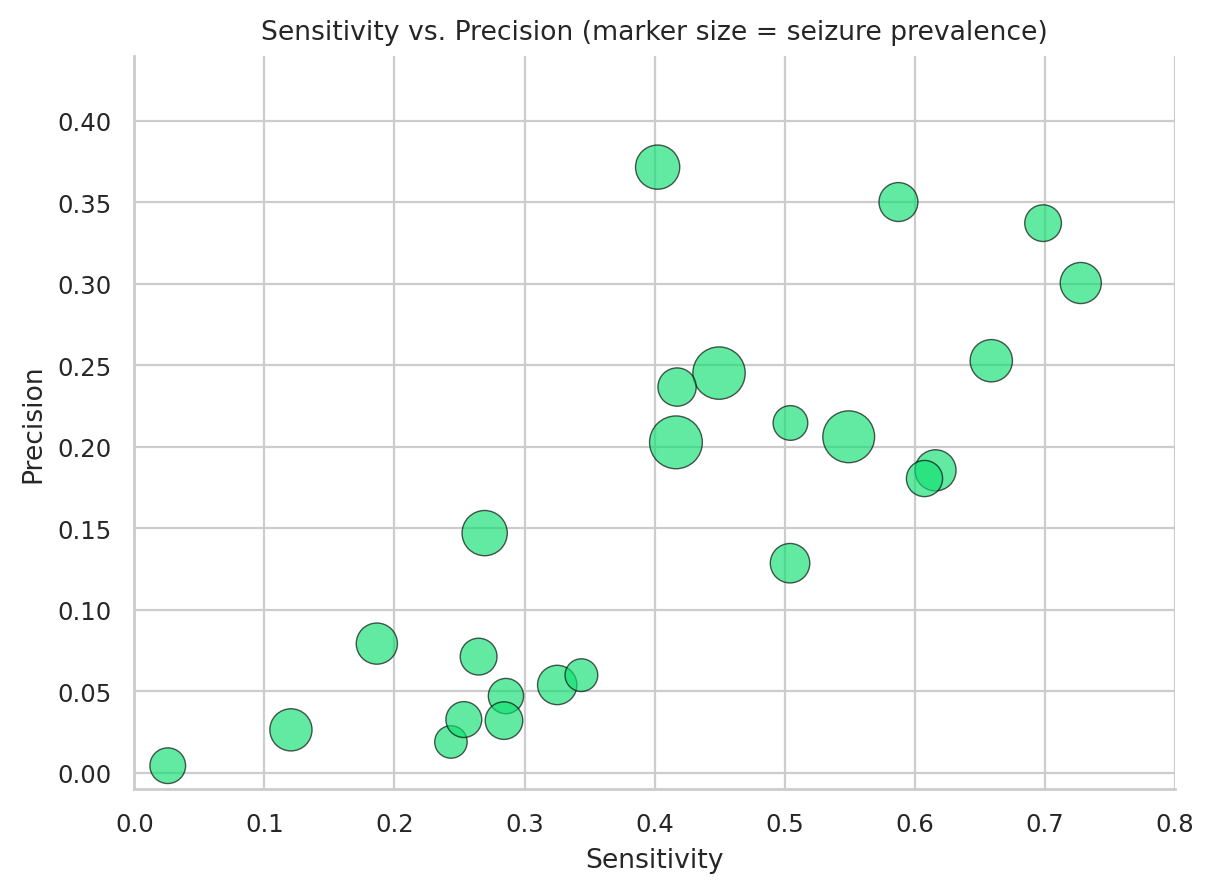

In [383]:
# ---------------------------------------------------------------------------
# 3. Figure 2 : sensitivity vs precision with prevalence as marker size
# ---------------------------------------------------------------------------

from adjustText import adjust_text

plt.rcParams.update({
    "font.size": 11,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.dpi": 200
})


fig, ax = plt.subplots(figsize=(6.2, 4.6))

# Marker size represents seizure prevalence
# prevalence is stored as a fraction (0-1)
sizes = 80 + 2500 * np.sqrt(g["prevalence"])

ax.scatter(
    g["sensitivity"],
    g["precision"],
    s=sizes,
    color=GREEN,
    alpha=0.65,
    edgecolor="black",
    linewidth=0.5,
    zorder=3
)


# --------------------------------------------------
# Patient labels (automatically adjusted)
# --------------------------------------------------

# texts = []

# for x, y, name in zip(
#     g["sensitivity"],
#     g["precision"],
#     g["patient"]
# ):
#     texts.append(
#         ax.text(
#             x,
#             y,
#             name.replace("chb", ""),
#             fontsize=7.5,
#             color="#333333"
#         )
#     )

# adjust_text(
#     texts,
#     ax=ax,
#     expand_points=(1.2, 1.2),
#     expand_text=(1.2, 1.2),
#     arrowprops=dict(
#         arrowstyle="-",
#         color="gray",
#         lw=0.5
#     )
# )


# --------------------------------------------------
# Size legend
# --------------------------------------------------

# legend_values = [0.1, 0.5, 1.0]  # percentages

# for value in legend_values:
#     ax.scatter(
#         [],
#         [],
#         s=80 + 2500*np.sqrt(value/100),
#         color=ORANGE,
#         alpha=0.65,
#         edgecolor="black",
#         linewidth=0.5,
#         label=f"{value:.1f}%"
#     )



ax.set_xlabel("Sensitivity")
ax.set_ylabel("Precision")
ax.set_title("Sensitivity vs. Precision (marker size = seizure prevalence)")

ax.set_xlim(0, 0.8)
ax.set_ylim(-0.01, 0.44)

fig.tight_layout()

fig.savefig(
    "figure2_sens_vs_prec_prevalence.png",
    bbox_inches="tight"
)

print("\nSaved figure2_sens_vs_prec_prevalence.png")

## 1.3 Spearman correlation

> Given the high imbalance, spearman was used

In [ ]:
# from scipy.stats import spearmanr

# rho, p = spearmanr(
#     patient["prevalence"],
#     patient["precision"]
# )

# print(rho, p)

TypeError: string indices must be integers, not 'str'

> A weak positive monotonic relationship was observed between seizure prevalence and precision across patients (Spearman's ρ = 0.33), although this association was not statistically significant (p = 0.111).

## 1.4 ROC AUC vs. F1

In [385]:
patient_auc = (
    segments
    .groupby("patient")
    .agg(
        roc_auc=("roc_auc", "median"),
        f1=("seg_f1", "median")
    )
    .reset_index()
)

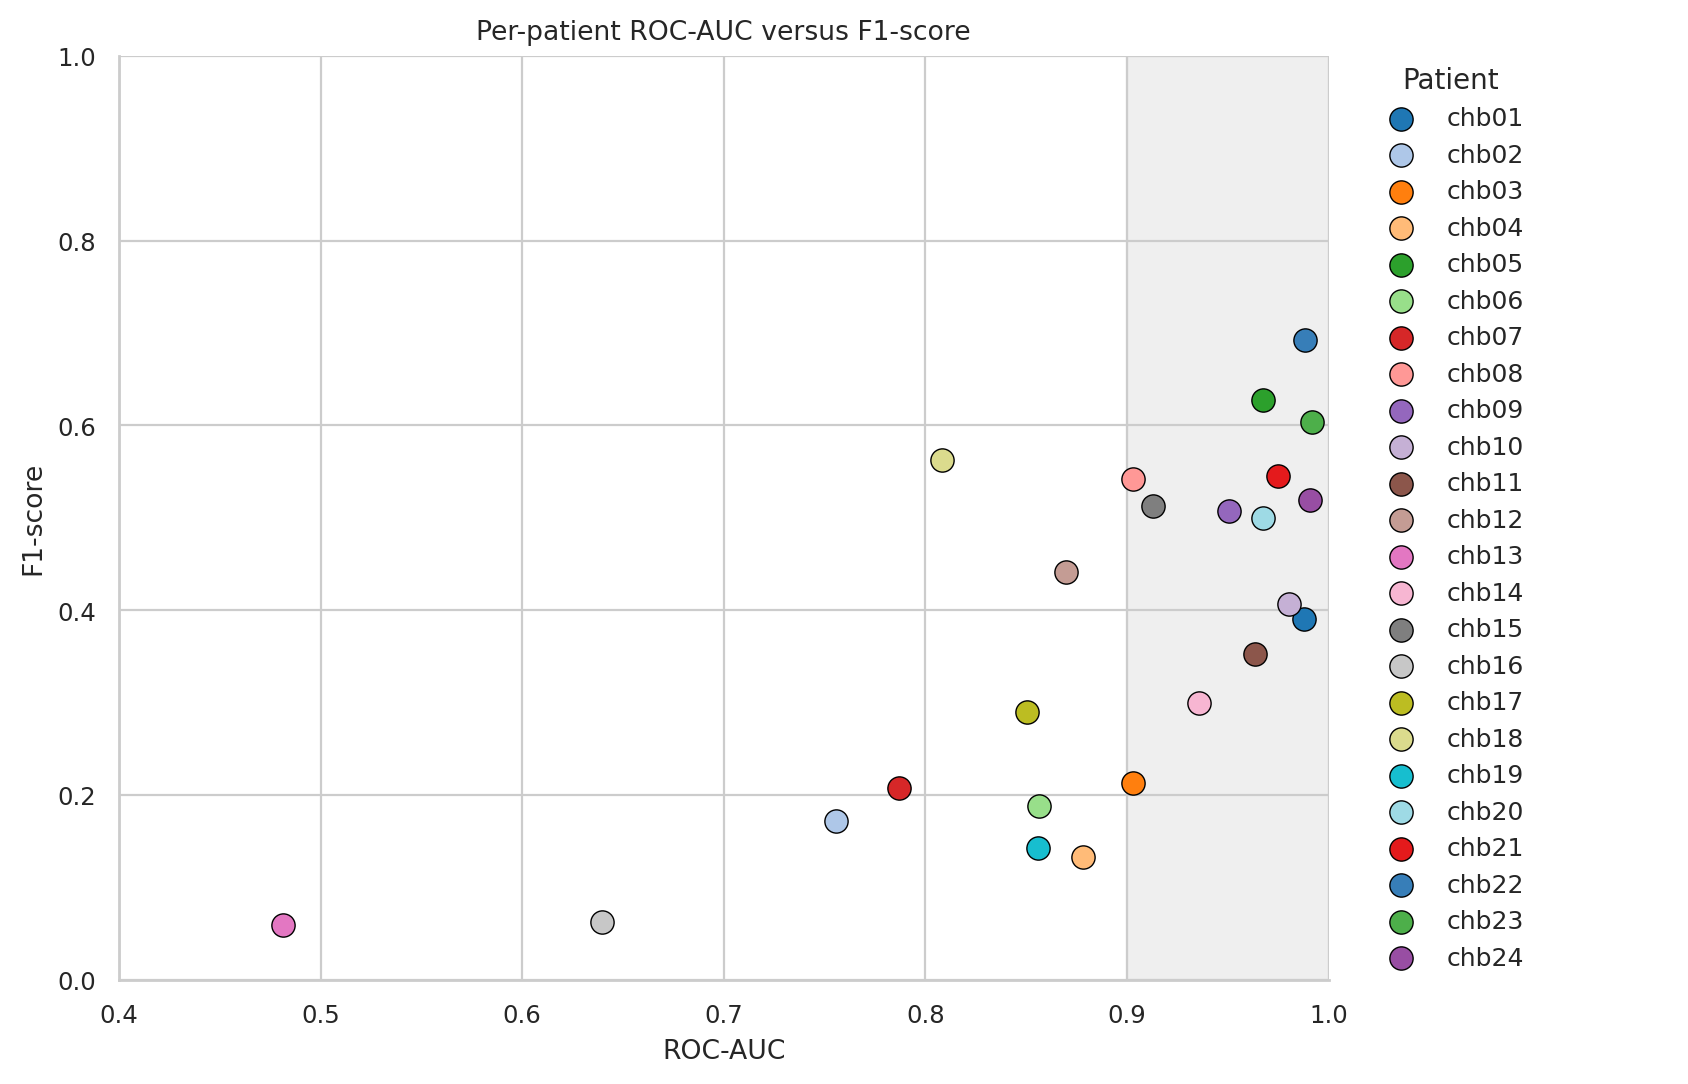

In [386]:
import matplotlib.pyplot as plt
import numpy as np

# Sort by patient (optional)
patient_auc = patient_auc.sort_values("patient").reset_index(drop=True)

# Create figure with two columns:
# left = scatter plot, right = legend
fig = plt.figure(figsize=(10, 6))
gs = fig.add_gridspec(1, 2, width_ratios=[4, 1], wspace=0.05)

ax = fig.add_subplot(gs[0, 0])
ax_leg = fig.add_subplot(gs[0, 1])

# -----------------------------------
# Shade ROC-AUC >= 0.90
# -----------------------------------
ax.axvspan(
    0.90,
    1.00,
    color="lightgray",
    alpha=0.35,
    zorder=0
)

# -----------------------------------
# One colour per patient
# -----------------------------------
colors = (
    list(plt.cm.tab20.colors)
    + list(plt.cm.Set1.colors)
    + list(plt.cm.Dark2.colors)
)

colors = colors[:len(patient_auc)]

for color, (_, row) in zip(colors, patient_auc.iterrows()):
    ax.scatter(
        row["roc_auc"],
        row["f1"],
        s=70,
        color=color,
        edgecolor="black",
        linewidth=0.5,
        label=row["patient"]
    )

# -----------------------------------
# Main plot formatting
# -----------------------------------
ax.set_xlabel("ROC-AUC")
ax.set_ylabel("F1-score")
ax.set_title("Per-patient ROC-AUC versus F1-score")

ax.set_xlim(0.4, 1.0)
ax.set_ylim(0, 1)

# -----------------------------------
# Legend panel
# -----------------------------------
handles, labels = ax.get_legend_handles_labels()

ax_leg.legend(
    handles,
    labels,
    title="Patient",
    loc="center left",
    frameon=False,
    fontsize=9,
    title_fontsize=10,
    borderaxespad=0
)

ax_leg.axis("off")

plt.show()

## 1.5 Record level analysis

In [ ]:
tmp = segments.copy()
tmp["has_seizure"] = tmp["n_seizure_windows"] > 0

patient_fp = (
    tmp.groupby(["patient", "has_seizure"])["fp"]
       .sum()
       .unstack(fill_value=0)
       .rename(columns={
           False: "fp_non_seizure_records",
           True: "fp_seizure_records"
       })
)

patient_fp["total_fp"] = (
    patient_fp["fp_non_seizure_records"] +
    patient_fp["fp_seizure_records"]
)

patient_fp["pct_seizure_records"] = (
    100 * patient_fp["fp_seizure_records"] /
    patient_fp["total_fp"]
)

patient_fp["pct_non_seizure_records"] = (
    100 * patient_fp["fp_non_seizure_records"] /
    patient_fp["total_fp"]
)

patient_fp = patient_fp.round(1)

patient_fp

has_seizure,fp_non_seizure_records,fp_seizure_records,total_fp,pct_seizure_records,pct_non_seizure_records
patient,,,,,
chb01,135,170,305,55.7,44.3
chb02,277,129,406,31.8,68.2
chb03,654,279,933,29.9,70.1
chb04,1627,308,1935,15.9,84.1
chb05,484,122,606,20.1,79.9
chb06,52,294,346,85.0,15.0
chb07,837,293,1130,25.9,74.1
chb08,378,130,508,25.6,74.4
chb09,156,49,205,23.9,76.1


In [ ]:
tmp = segments.copy()
tmp["has_seizure"] = tmp["n_seizure_windows"] > 0

summary = (
    tmp.groupby(["patient", "has_seizure"])
       .agg(
           total_fp=("fp", "sum"),
           total_windows=("n_windows", "sum"),
           n_records=("record", "count")
       )
)

summary["fp_per_record"] = (
    summary["total_fp"] / summary["n_records"]
)

summary["fp_per_1000_windows"] = (
    summary["total_fp"] / summary["total_windows"] * 1000
)

summary

total_fp  total_windows  n_records  fp_per_record  \
patient has_seizure                                                      
chb01   False             135          48716         35       3.857143   
        True              170           9549          7      24.285714   
chb02   False             277          63261         33       8.393939   
        True              129           3254          3      43.000000   
chb03   False             654          59430         31      21.096774   
        True              279          10059          7      39.857143   
chb04   False            1627         279058         39      41.717949   
        True              308          15334          3     102.666667   
chb05   False             484          65183         34      14.235294   
        True              122           7185          5      24.400000   
chb06   False              52          78383         11       4.727273   
        True              294          37264          7      42.000000   
chb07   False             837         109729         16      52.312500   
        True              293          14917          3      97.666667   
chb08   False             378          23007         15      25.200000   
        True              130           7185          5      26.000000   
chb09   False             156         106198         16       9.750000   
        True               49          13790          3      16.333333   
chb10   False              79          61396         18       4.388889   
        True              114          20163          7      16.285714   
chb11   False             428          54623         32      13.375000   
        True               77           4014          3      25.666667   
chb12   False             396          17735         11      36.000000   
        True              261          13912         10      26.100000   
chb13   False             205          47925         25       8.200000   
        True              761          11496          8      95.125000   
chb14   False             189          36423         19       9.947368   
        True               46          10059          7       6.571429   
chb15   False             922          49363         26      35.461538   
        True              773          20131         14      55.214286   
chb16   False             102          24921         13       7.846154   
        True              135           8622          6      22.500000   
chb17   False             217          33369         18      12.055556   
        True               39           4320          3      13.000000   
chb18   False             112          57515         30       3.733333   
        True               59           8091          6       9.833333   
chb19   False             663          51759         27      24.555556   
        True              157           4208          3      52.333333   
chb20   False             341          41758         23      14.826087   
        True               66           7995          6      11.000000   
chb21   False             193          55592         29       6.655172   
        True               25           5504          4       6.250000   
chb22   False             105          53680         28       3.750000   
        True                9           4311          3       3.000000   
chb23   False             219          33771          6      36.500000   
        True              118          12891          3      39.333333   
chb24   False              53          17819         10       5.300000   
        True               62          17244         12       5.166667   

                     fp_per_1000_windows  
patient has_seizure                       
chb01   False                   2.771163  
        True                   17.802911  
chb02   False                   4.378685  
        True                   39.643516  
chb03   False                  11.004543  
        True       

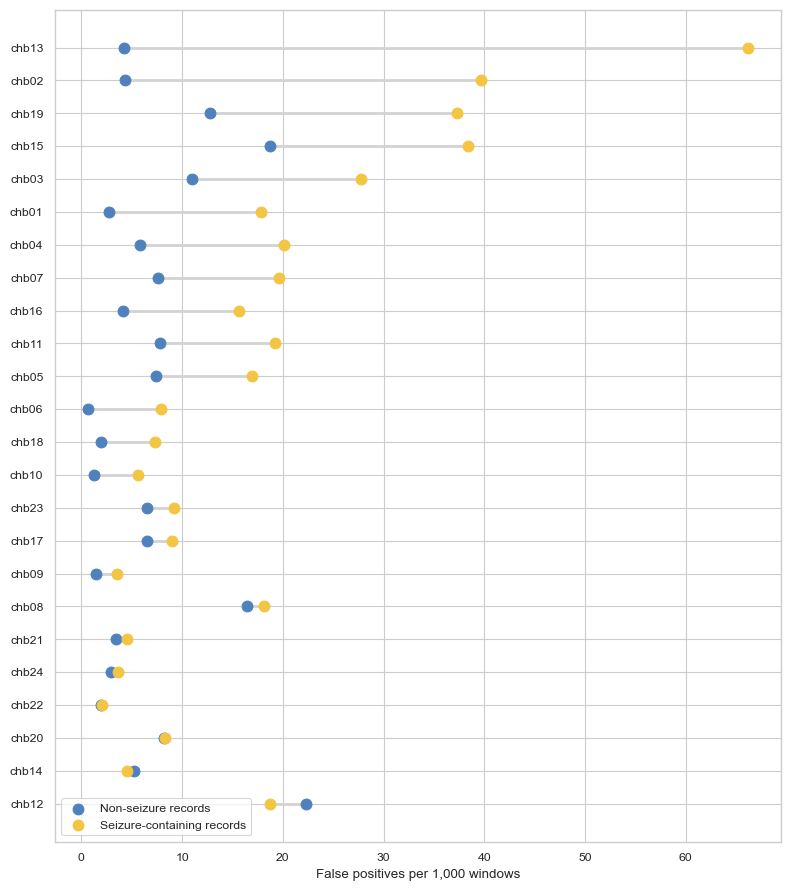

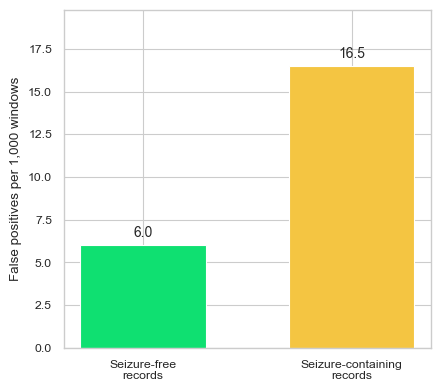

In [ ]:
import matplotlib.pyplot as plt

GREEN = "#0fe071"
ORANGE = "#f4c542"

labels = ["Seizure-free\nrecords", "Seizure-containing\nrecords"]
values = [fp_density_non, fp_density_seiz]
colors = [GREEN, ORANGE]

plt.figure(figsize=(4.5, 4))

bars = plt.bar(labels, values, color=colors, width=0.6)

# Add values above bars
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.3,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylabel("False positives per 1,000 windows")
plt.ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

In [ ]:
fp_non = 8824
fp_seiz = 4476

windows_non = 1470614
windows_seiz = 271498

In [ ]:
fp_density_non = fp_non / windows_non * 1000
fp_density_seiz = fp_seiz / windows_seiz * 1000

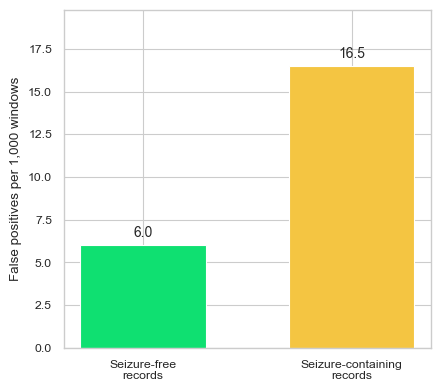

In [ ]:
import matplotlib.pyplot as plt

GREEN = "#0fe071"
ORANGE = "#f4c542"

labels = ["Seizure-free\nrecords", "Seizure-containing\nrecords"]
values = [fp_density_non, fp_density_seiz]
colors = [GREEN, ORANGE]

plt.figure(figsize=(4.5, 4))

bars = plt.bar(labels, values, color=colors, width=0.6)

# Add values above bars
for bar in bars:
    h = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        h + 0.3,
        f"{h:.1f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.ylabel("False positives per 1,000 windows")
plt.ylim(0, max(values) * 1.2)

plt.tight_layout()
plt.show()

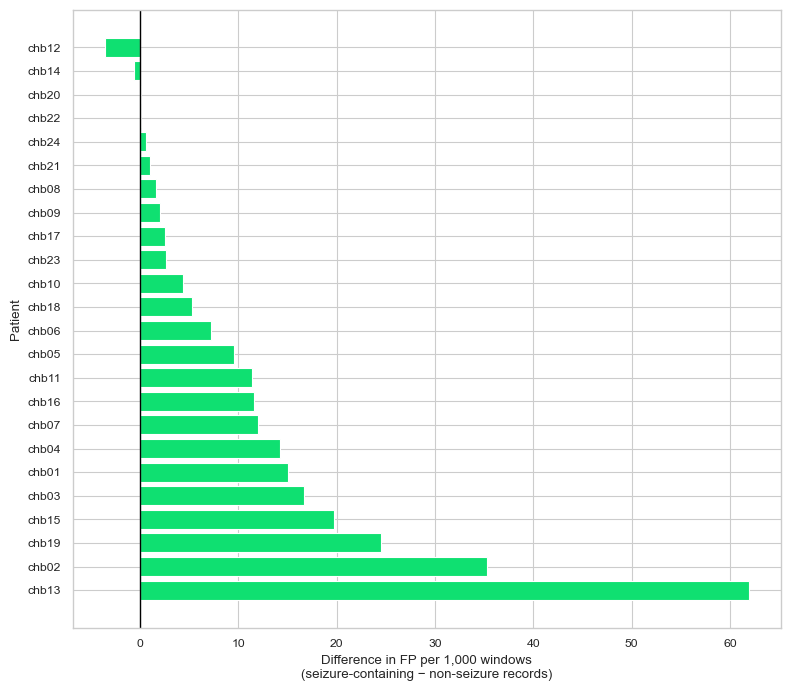

In [ ]:
import matplotlib.pyplot as plt

GREEN = "#0fe071"

plt.figure(figsize=(8, 7))

plt.barh(
    pivot.index,
    pivot["difference"],
    color=GREEN
)

plt.axvline(0, color="black", linewidth=1)

plt.xlabel("Difference in FP per 1,000 windows\n(seizure-containing − non-seizure records)")
plt.ylabel("Patient")

plt.tight_layout()
plt.show()